# Banded Peak Ranch (Navajo River basin) snowmelt runoff onset — regional viewer

Exploratory regional maps (**not** manuscript figures): the multi-year median runoff
onset over a hillshade, the same map with a zoomed-out context inset, and per-water-year
anomalies against that median — for the Navajo River basin above the Oso Diversion, the
watershed containing Banded Peak Ranch (BPR), a collaborator AOI in the San Juan
Mountains of southern Colorado.

Data comes from the **multiscale visualization pyramid** ([`../../pyramid/`](../../pyramid/)),
read one level at a time with `build_pyramid.open_pyramid_level` — the same source the
global figures and the other regional viewers ([`alps/`](../alps/), [`iceland/`](../iceland/))
use.

Styling, per-variable colour limits, scalebars and the context inset all come from
`global_snowmelt_runoff_onset.plot_utils`, whose module docstring is the repository's
**figure conventions** reference. Figures are written to `figures/<config.version>/`.

Moved here 2026-09 from `global_snowmelt_runoff_onset_analysis` (`analyses/case_studies/bpr/`)
and rebuilt on this notebook's shape. The basin is far smaller than the Alps or Iceland
(~15 x 29 km vs. hundreds to thousands of km), so the pyramid level, the buffers, and the
anomaly grid are all sized down accordingly — see the comments at each choice below.


In [1]:
import os

import geopandas as gpd
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import rioxarray  # noqa: F401  -- registers the .rio accessor
from matplotlib.gridspec import GridSpec

from global_snowmelt_runoff_onset.config import Config
from global_snowmelt_runoff_onset.plot_utils import (
    HILLSHADE_KW,
    add_context_inset,
    add_scalebar,
    create_diverging_colorbar,
    create_month_colorbar,
    load_hillshade,
    orthographic_locator_map,
    style_map_axes,
    variable_kw,
)

from global_snowmelt_runoff_onset.pyramid import open_pyramid_level


In [2]:
config = Config('config/global_config_v10.txt')

# figures are versioned like results/: the v9 renders stay in figures/v9/
FIG_DIR = f'figures/{config.version}'
os.makedirs(FIG_DIR, exist_ok=True)

# The basin is tiny next to the Alps/Iceland (~15 x 29 km), so read the pyramid
# much finer: level 0 (~80 m, native resolution) for the region -- the extra
# detail costs nothing at this footprint -- and level 4 (~1.3 km) is plenty for
# the zoomed-out inset over the surrounding San Juan Mountains.
REGION_LEVEL = 0
CONTEXT_LEVEL = 4

# How far past the basin outline each view extends, in projected metres.
# MAP_BUFFER is proportionate to the basin's own scale (a few km); CONTEXT_BUFFER
# has to reach the surrounding mountains regardless of how small the basin is,
# so it isn't scaled down the same way.
MAP_BUFFER = 2_000
CONTEXT_BUFFER = 100_000


----------------------------------------
Configuration loaded:
config_name = global_config_v10
version = v10
resolution = 0.00072000072000072
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 84.048
bbox_bottom = -63.4074
expected_grid_shape = 204800, 499998
expected_tile_grid = 100, 245
wy_start = 2015
wy_end = 2025
trailing_buffer_days = 120
bands = vv
mountain_snow_only = False
low_backscatter_threshold = 0.001
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
spatial_chunk_dim_zarr_output = 2048
inner_chunk_dim = 256
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow_v10.geojson
snow_phenology_zarr_store_azure_path = snowmelt/modis_snow_phenology/modis_snow_phenology_v1
global_runoff_icechunk_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10
release_tag = v10.0
global_runoff_multiscale_azure_prefix = snowmelt/snowmelt_runoff_onset/

## Region of interest

Everything is plotted in a projected, metre-based CRS (plot_utils convention 4) so shapes, areas and the scalebar are all honest.


In [3]:
GEOM_DIR = 'geometries/BPR_Shapefiles'

# the basin above the Oso Diversion -- the entire outline used for the clip AND
# drawn on every panel below, same as the pre-migration notebook (nr_to_o_gdf there)
basin_gdf = gpd.read_file(f'{GEOM_DIR}/NavajoRiver_Basin_toOsoDiv.shp').to_crs('EPSG:4326')

# the basin's own UTM zone, picked from its bounds
REGION_CRS = basin_gdf.estimate_utm_crs()
basin_gdf.to_crs(REGION_CRS)


,fid,cat,value,label,geometry
0,1.0,2,1,None,"POLYGON ((345741.868 4099801.88, 345741.962 40..."
1,2.0,3,1,None,"POLYGON ((345733.445 4099791.757, 345733.539 4..."
2,3.0,4,1,None,"POLYGON ((345725.021 4099781.634, 345725.115 4..."
3,4.0,5,1,None,"POLYGON ((345716.598 4099771.512, 345716.692 4..."
4,5.0,6,1,None,"POLYGON ((345708.174 4099761.389, 345708.268 4..."
5,6.0,7,1,None,"POLYGON ((345699.751 4099751.266, 345699.844 4..."
6,7.0,8,1,None,"POLYGON ((345691.327 4099741.144, 345691.421 4..."
7,8.0,9,1,None,"POLYGON ((345682.904 4099731.021, 345682.997 4..."
8,9.0,10,1,None,"POLYGON ((345674.48 4099720.898, 345674.574 40..."
9,10.0,11,1,None,"POLYGON ((345666.056 4099710.775, 345666.15 40..."


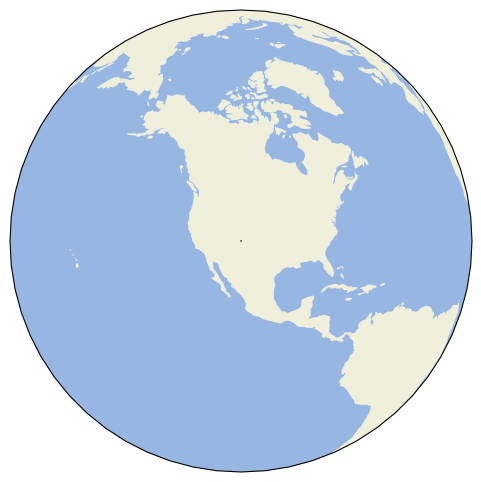

In [4]:
ax = orthographic_locator_map(basin_gdf)
ax.figure.savefig(f'{FIG_DIR}/orthographic_context_map.png',
                  dpi=300, transparent=True)


## Hillshade and pyramid read

In [5]:
# hillshades for the two view scales, both reprojected into REGION_CRS. The
# extra 50 km keeps the reprojected edge outside the plotted extent.
bpr_hillshade_da = load_hillshade(basin_gdf, buffer=MAP_BUFFER + 50_000, crs=REGION_CRS)
bpr_context_hillshade_da = load_hillshade(basin_gdf, buffer=CONTEXT_BUFFER, crs=REGION_CRS)
bpr_hillshade_da


<xarray.DataArray (y: 114, x: 178)> Size: 81kB
array([[218.1941 , 199.1071 , 154.05942, ...,       nan,       nan,
              nan],
       [      nan, 201.70044, 159.3842 , ...,       nan,       nan,
              nan],
       [      nan, 205.0192 , 174.51295, ...,       nan,       nan,
              nan],
       ...,
       [      nan,       nan,       nan, ..., 237.65555, 234.57277,
              nan],
       [      nan,       nan,       nan, ..., 185.97185, 186.01553,
        188.7096 ],
       [      nan,       nan,       nan, ..., 140.29753, 135.86972,
        146.61934]], shape=(114, 178), dtype=float32)
Coordinates:
  * y            (y) float64 912B 4.18e+06 4.178e+06 ... 4.043e+06 4.042e+06
  * x            (x) float64 1kB 2.449e+05 2.462e+05 ... 4.592e+05 4.604e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        Adobe Photoshop CS5 Macintosh
    TIFFTAG_DATETIME:        2012:07:20 09:39:49
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              nan

In [6]:
# level 0 is one of the pyramid's big fine levels, so read it dask-backed
# (chunks='auto') rather than the plain lazy-array default the coarser levels use.
# clip_box first (cheap bbox pre-filter out to the map buffer, for the hillshade
# margin), then clip(geometry) to the basin polygon itself -- same two-step the
# pre-migration notebook used -- so only the basin interior carries data; outside
# the outline, within the buffered view, only the hillshade shows through.
bpr_ds = (
    open_pyramid_level(config, REGION_LEVEL, chunks='auto')[['runoff_onset_median', 'runoff_onset']]
    .rio.write_crs('EPSG:4326')
    .rio.clip_box(*basin_gdf.to_crs(REGION_CRS).buffer(MAP_BUFFER + 5_000).total_bounds,
                  crs=REGION_CRS)
    .rio.clip(basin_gdf.geometry)
    .astype('float32')
    .compute()
    .rio.reproject(REGION_CRS)
)
bpr_ds


<xarray.Dataset> Size: 4MB
Dimensions:              (x: 199, y: 381, water_year: 11)
Coordinates:
  * x                    (x) float64 2kB 3.442e+05 3.443e+05 ... 3.592e+05
  * y                    (y) float64 3kB 4.125e+06 4.125e+06 ... 4.096e+06
  * water_year           (water_year) int64 88B 2015 2016 2017 ... 2024 2025
    spatial_ref          int64 8B 0
Data variables:
    runoff_onset_median  (y, x) float32 303kB nan nan nan nan ... nan nan nan
    runoff_onset         (water_year, y, x) float32 3MB nan nan nan ... nan nan
Attributes:
    title:           Global snowmelt runoff onset from Sentinel-1 SAR
    config_version:  v10

In [7]:
bpr_ds['runoff_onset_anomaly'] = (
    bpr_ds['runoff_onset'] - bpr_ds['runoff_onset_median'])

water_years = bpr_ds['water_year'].values
N_YEARS = len(water_years)

# every view in this notebook shares one extent, so panels are comparable
REGION_BOUNDS = basin_gdf.to_crs(REGION_CRS).buffer(MAP_BUFFER).total_bounds

# styling comes from the per-variable convention in plot_utils, not from
# hand-written cmap/vmin/vmax here (plot_utils convention 1)
MEDIAN_KW = variable_kw('runoff_onset_median')
ANOM_KW = variable_kw('runoff_onset_anomaly')

# year counts are derived, never hardcoded (plot_utils convention 3). Two lines --
# this notebook's narrower main-map figure (basin is tall and skinny) doesn't have
# the horizontal room alps/iceland's wider maps do for the label on one line.
MEDIAN_LABEL = f'{N_YEARS}-year median runoff onset date\n[day of water year]'
EARLIER_TEXT = f'earlier than {N_YEARS}-yr median'
LATER_TEXT = f'later than {N_YEARS}-yr median'

print(f'{N_YEARS} water years: WY{water_years.min()}-WY{water_years.max()}')
print(f'{REGION_CRS}, extent {(REGION_BOUNDS[2] - REGION_BOUNDS[0]) / 1e3:.1f} x '
      f'{(REGION_BOUNDS[3] - REGION_BOUNDS[1]) / 1e3:.1f} km')


11 water years: WY2015-WY2025
EPSG:32613, extent 18.5 x 32.5 km


## Median runoff onset map

Two renders of the same map: bare, and with a zoomed-out context inset that reuses the identical variable, hillshade, colormap and limits. The basin outline (white, black halo) is overlaid on both, and on every anomaly panel below -- same outline used to clip the data, so everything inside it is real and everything outside is hillshade only.


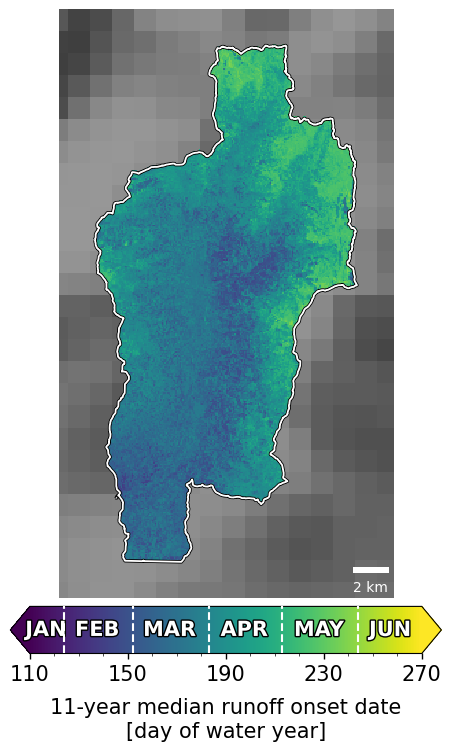

In [8]:
fig = plt.figure(figsize=(4.4, 7.4), layout='constrained')
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.08], hspace=0.00)
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

bpr_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
bpr_ds['runoff_onset_median'].plot.imshow(ax=ax, add_colorbar=False, zorder=1,
                                          **MEDIAN_KW)
basin_gdf.to_crs(REGION_CRS).boundary.plot(
    ax=ax, color='white', linewidth=1.3, zorder=2,
    path_effects=[path_effects.withStroke(linewidth=2.5, foreground='black')])
style_map_axes(ax, REGION_BOUNDS)
# frameless (convention 6), so the colour is picked for this corner's backdrop
add_scalebar(ax, location='lower right', color='white')

create_month_colorbar(MEDIAN_KW['vmin'], MEDIAN_KW['vmax'], hemisphere='northern',
                      ax=cax, label=MEDIAN_LABEL)

fig.savefig(f'{FIG_DIR}/median_runoff_onset_map.png', dpi=300, bbox_inches='tight')


In [9]:
# same variable, coarser level, much wider footprint -- the inset's content.
# Clipped to the basin polygon too, for the same reason as bpr_ds: at this zoom
# the basin is a tiny sliver, so it should read as a small patch of real data
# inside a much larger hillshade-only surrounding, not a data-filled box.
bpr_context_da = (
    open_pyramid_level(config, CONTEXT_LEVEL)['runoff_onset_median']
    .rio.write_crs('EPSG:4326')
    .rio.clip_box(*basin_gdf.to_crs(REGION_CRS).buffer(CONTEXT_BUFFER).total_bounds,
                  crs=REGION_CRS)
    .rio.clip(basin_gdf.geometry)
    .astype('float32')
    .compute()
    .rio.reproject(REGION_CRS)
)
bpr_context_da


<xarray.DataArray 'runoff_onset_median' (y: 23, x: 12)> Size: 1kB
array([[ nan,  nan,  nan,  nan,  nan,  nan, 219., 218., 212.,  nan,  nan,
         nan],
       [ nan,  nan,  nan,  nan,  nan,  nan, 217., 215., 210., 211.,  nan,
         nan],
       [ nan,  nan,  nan,  nan,  nan,  nan, 199., 198., 196., 210.,  nan,
         nan],
       [ nan,  nan,  nan,  nan,  nan,  nan, 199., 187., 193., 209., 217.,
         nan],
       [ nan,  nan,  nan,  nan,  nan, 200., 189., 190., 201., 217., 209.,
        220.],
       [ nan,  nan, 188., 184., 192., 189., 183., 189., 207., 206., 210.,
        220.],
       [ nan,  nan, 188., 179., 180., 178., 180., 183., 199., 193., 210.,
        220.],
       [190., 184., 180., 177., 177., 170., 180., 183., 199., 193., 206.,
        208.],
       [193., 184., 183., 177., 170., 170., 169., 184., 187., 178., 210.,
        215.],
       [193., 184., 183., 177., 175., 168., 158., 167., 168., 167., 204.,
        210.],
...
       [ nan,  nan, 187., 179., 170., 170., 164., 165., 186.,  nan,  nan,
         nan],
       [ nan,  nan, 184., 176., 170., 164., 159., 161., 181., 212.,  nan,
         nan],
       [ nan,  nan, 176., 178., 168., 163., 163., 168., 181.,  nan,  nan,
         nan],
       [ nan,  nan, 173., 172., 167., 163., 161., 171., 182.,  nan,  nan,
         nan],
       [ nan, 170., 168., 167., 167., 163., 160., 181., 189.,  nan,  nan,
         nan],
       [ nan, 162., 161., 165., 165., 161., 164., 177., 189.,  nan,  nan,
         nan],
       [ nan,  nan, 155., 162., 161., 161., 171., 182., 186.,  nan,  nan,
         nan],
       [ nan,  nan, 159., 163., 168.,  nan,  nan,  nan, 184.,  nan,  nan,
         nan],
       [ nan,  nan, 161., 164.,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan],
       [ nan,  nan, 166., 166., 166.,  nan,  nan,  nan,  nan,  nan,  nan,
         nan]], dtype=float32)
Coordinates:
  * y            (y) float64 184B 4.124e+06 4.123e+06 ... 4.099e+06 4.097e+06
  * x            (x) float64 96B 3.444e+05 3.456e+05 ... 3.565e+05 3.577e+05
    spatial_ref  int64 8B 0
Attributes:
    description:  Median estimated day of water year of snowmelt runoff onset...
    _FillValue:   nan

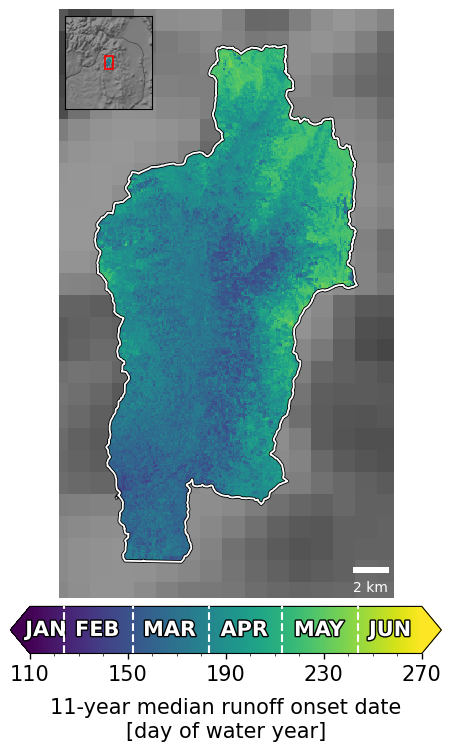

In [10]:
fig = plt.figure(figsize=(4.4, 7.4), layout='constrained')
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.08], hspace=0.00)
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

bpr_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
bpr_ds['runoff_onset_median'].plot.imshow(ax=ax, add_colorbar=False, zorder=1,
                                          **MEDIAN_KW)
basin_gdf.to_crs(REGION_CRS).boundary.plot(
    ax=ax, color='white', linewidth=1.3, zorder=2,
    path_effects=[path_effects.withStroke(linewidth=2.5, foreground='black')])
style_map_axes(ax, REGION_BOUNDS)

# Identical variable, hillshade, colormap and limits -- just zoomed out. The red
# box is this map's extent, read straight off its limits. Explicit `bounds` (the
# buffered region box) crops the NaN corners that reprojecting a lon/lat clip
# into a metric CRS leaves behind.
add_context_inset(ax, bpr_context_da, bpr_context_hillshade_da,
                  loc='upper left', size='26%', borderpad=0.5,
                  data_kw=MEDIAN_KW,
                  bounds=basin_gdf.to_crs(REGION_CRS).buffer(CONTEXT_BUFFER).total_bounds)

# scalebar opposite the inset so the two never compete for a corner
add_scalebar(ax, location='lower right', color='white')

create_month_colorbar(MEDIAN_KW['vmin'], MEDIAN_KW['vmax'], hemisphere='northern',
                      ax=cax, label=MEDIAN_LABEL)

fig.savefig(f'{FIG_DIR}/median_runoff_onset_map_with_context.png',
            dpi=300, bbox_inches='tight')


## Per-water-year anomaly maps

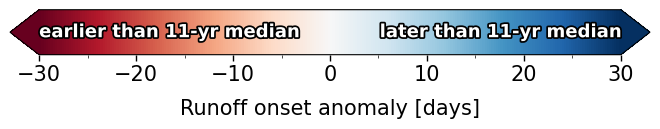

In [11]:
# standalone colorbar, for pasting alongside the *_no_cbar grid. Default ticks
# already land on -30..30 by 10, so only the minor spacing needs stating.
figcbar = create_diverging_colorbar(
    ANOM_KW['vmin'], ANOM_KW['vmax'], cmap=ANOM_KW['cmap'],
    label='Runoff onset anomaly [days]',
    minor_tick_spacing=5,
    left_text=EARLIER_TEXT, right_text=LATER_TEXT,
)
figcbar.savefig(f'{FIG_DIR}/runoff_onset_anomaly_colorbar_horizontal.png',
                bbox_inches='tight', dpi=300, facecolor='white', pad_inches=0.1)


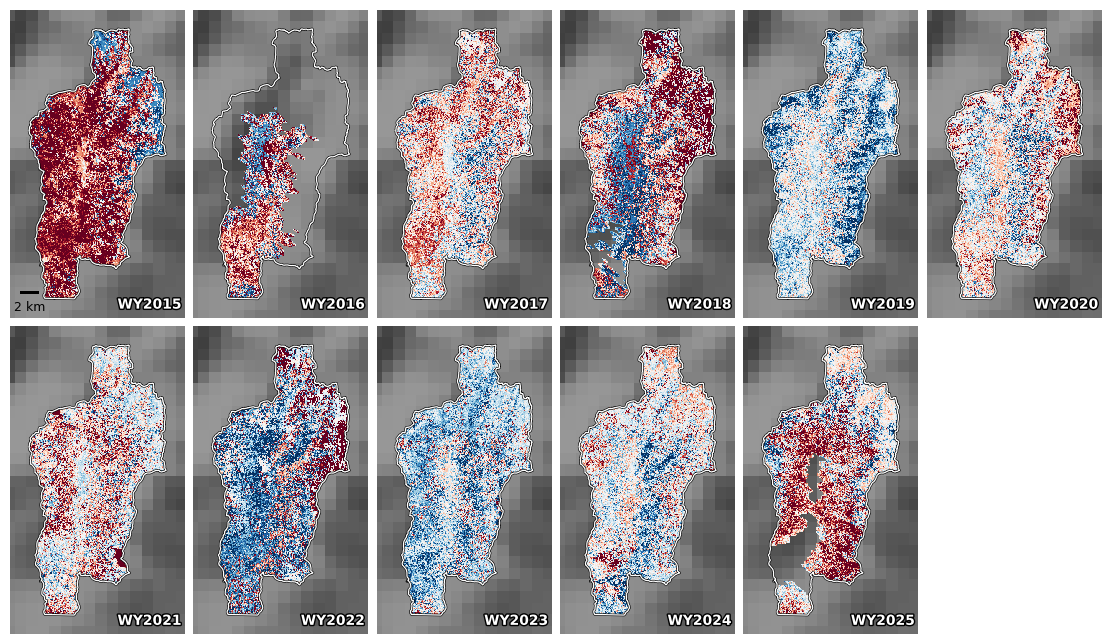

In [12]:
# 2 x 6 = 12 panel slots; leftovers stay blank. The basin is narrow and tall
# (~19 x 33 km with the map buffer) rather than wide like the Alps/Iceland, so
# packing panels with more columns than rows keeps the composite from becoming
# an unwieldy vertical strip. layout='compressed' squeezes the dead space that
# equal-aspect panels otherwise leave inside their grid cells.
NROWS, NCOLS = 2, 6
fig, axgrid = plt.subplots(NROWS, NCOLS, figsize=(11.0, 6.4), layout='compressed')
axs = list(axgrid.flat)
for ax in axs:
    ax.axis('off')

for i, (wy, ax) in enumerate(zip(water_years, axs)):
    bpr_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
    bpr_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(
        ax=ax, add_colorbar=False, zorder=1, **ANOM_KW)
    basin_gdf.to_crs(REGION_CRS).boundary.plot(
        ax=ax, color='white', linewidth=0.9, zorder=2,
        path_effects=[path_effects.withStroke(linewidth=1.8, foreground='black')])
    ax.text(0.98, 0.02, f'WY{wy}', transform=ax.transAxes,
            ha='right', va='bottom', color='white', fontweight='bold',
            fontsize=10,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='black')])
    style_map_axes(ax, REGION_BOUNDS)
    if i == 0:  # every panel shares REGION_BOUNDS, so one scalebar is enough
        add_scalebar(ax, location='lower left', color='black',
                     font_properties={'size': 9})

fig.savefig(f'{FIG_DIR}/anomaly_maps_{NROWS}{NCOLS}grid_no_cbar.png',
            dpi=300, bbox_inches='tight')


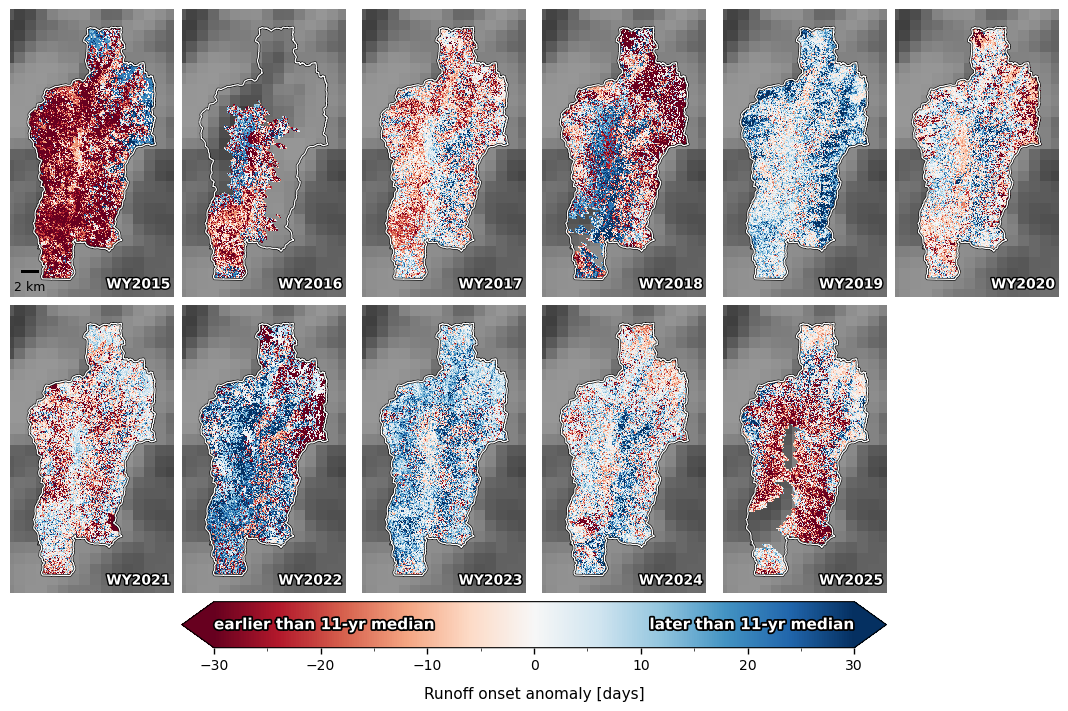

In [13]:
# same 2 x 6 grid plus a dedicated thin colorbar row underneath
NROWS, NCOLS = 2, 6
fig = plt.figure(figsize=(11.0, 7.0), layout='compressed')
gs = GridSpec(NROWS + 1, NCOLS, figure=fig,
              height_ratios=[1] * NROWS + [0.16])

axs = [fig.add_subplot(gs[r, c]) for r in range(NROWS) for c in range(NCOLS)]
for ax in axs:
    ax.axis('off')

for i, (wy, ax) in enumerate(zip(water_years, axs)):
    bpr_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
    bpr_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(
        ax=ax, add_colorbar=False, zorder=1, **ANOM_KW)
    basin_gdf.to_crs(REGION_CRS).boundary.plot(
        ax=ax, color='white', linewidth=0.9, zorder=2,
        path_effects=[path_effects.withStroke(linewidth=1.8, foreground='black')])
    ax.text(0.98, 0.02, f'WY{wy}', transform=ax.transAxes,
            ha='right', va='bottom', color='white', fontweight='bold',
            fontsize=10,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='black')])
    style_map_axes(ax, REGION_BOUNDS)
    if i == 0:  # every panel shares REGION_BOUNDS, so one scalebar is enough
        add_scalebar(ax, location='lower left', color='black',
                     font_properties={'size': 9})

# create_diverging_colorbar shrinks the end annotations to fit this narrower
# axes, so they can't collide mid-bar
cax = fig.add_subplot(gs[NROWS, 1:5])
create_diverging_colorbar(
    ANOM_KW['vmin'], ANOM_KW['vmax'], cmap=ANOM_KW['cmap'], ax=cax,
    label='Runoff onset anomaly [days]',
    minor_tick_spacing=5,
    left_text=EARLIER_TEXT, right_text=LATER_TEXT,
    label_fontsize=11, tick_labelsize=10,
    text_fontsize=11,
)

fig.savefig(f'{FIG_DIR}/anomaly_maps_{NROWS}{NCOLS}grid_w_cbar.png',
            dpi=300, bbox_inches='tight')
